# 多層スパースコーディングのコードのデモンストレーション

論文で用いたソースコードのデモンストレーションです。

In [1]:
# ============================================================
# 0. Setup — imports and one seed
# ============================================================

# --- Parallelism control ---------------------------------------------------
# 実行スレッドの設定
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import random
import sys
from pathlib import Path

import numpy as np
import csv
import torch
import matplotlib.pyplot as plt

_DEMO_DIR = Path.cwd()
sys.path.insert(0, str(_DEMO_DIR))

# --- Core imports ------------------------------------------------------------
# HierarchicalSparseCoding: 階層スパース符号化の本体（Config・辞書操作・可視化）
from HierarchicalSparseCoding import (
    Config,
    compute_effective_dictionaries,    # D1 @ D2 を合成した「有効辞書」を計算
    save_dictionary_grid,              # 辞書原子をグリッド画像として保存
    show_hsc_recon_examples_nlayer,    # N層の再構成例を表示（今回は未使用）
    sparsity_stats,                    # コードの疎性統計（L1平均・非零率）
)

# train_hsc: トレーニングパイプライン全体
from train_hsc import (
    train_main,                        # メイン学習ループ
    make_dataset_loaders,              # MNIST/DataLoader生成
    prepare_eval_batch,                # 評価用バッチをデバイス上に転送
    build_eval_inference_context,      # 推論に必要なコンテキスト(Ds,lambdas,betas,etas)を構築
    collect_validation_snapshot,       # 検証セットのloss/rec/latencyを一括計測
)

# --- Reproducibility seed ----------------------------------------------------
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cpu"
DATASET = "mnist"
EPOCHS = 25
BATCH_SIZE = 256
LAYER_DIMS = [256, 64]             # 論文のmain comparisonと同じ2層構成
LAMBDAS = [0.05, 0.05]             # L1正則化係数（各層共通）
BETAS = [1.0]                      # 層間伝播ゲート（デフォルト=全通過）

# --- Methods to compare ------------------------------------------------------
# Main-paper methods: ISTA / MFISTA / LISTA / Hybrid
# (Hybrid+MFISTAはappendixのablationなので省略)
MODES = ["ista", "mfista", "lista", "hybrid"]

# 各手法の推論時のステップ数設定
#   infer_steps : 反復推論（refinement）の回数
#   lista_steps : LISTA風のstage数（Hybrid以外では1）
METHOD_STEPS = {
    "ista": {"infer_steps": 50, "lista_steps": 1},
    "mfista": {"infer_steps": 20, "lista_steps": 1},
    "lista": {"infer_steps": 50, "lista_steps": 1}, #LISTAではinference_stepsは無視される。
    "hybrid": {"infer_steps": 5, "lista_steps": 1},
}

# Hybrid特有: pre-training用エポック数（LISTA初期化に使う）
HYBRID_PRETRAIN = 5

# --- Plotting constants ------------------------------------------------------
MODE_LABELS = {
    "ista": "ISTA",
    "mfista": "MFISTA",
    "lista": "LISTA",
    "hybrid": "Hybrid",
}
MODE_COLORS = {
    "ista": "#56B4E9",   # ColorPalette (oka)
    "mfista": "#E69F00",
    "lista": "#009E73",
    "hybrid": "#0072B2",
}
MODE_MARKERS = {"ista": "o", "mfista": "s", "lista": "^", "hybrid": "D"}

# --- Matplotlib style (paper-like) -------------------------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "#FCFCFD",
    "axes.edgecolor": "#222222",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

print(f"Dataset: {DATASET}")
print(f"Seed: {SEED}")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Dataset: mnist
Seed: 1
Device: cpu
PyTorch: 2.8.0


---

# 1. Train the shared two-layer models

論文の main comparison と同じ 2 層構成 `[256, 64]` を使い、各手法を **seed=1 のみ**で学習します。論文のような seed 平均・エラーバーは出さず、notebook では 1 本の再現しやすい曲線として表示します。

In [2]:
# ============================================================
# 1. Train main methods once
# ============================================================

results = {}

for mode in MODES:
    steps = METHOD_STEPS[mode]
    print(f"\n{'=' * 64}")
    print(f"Training {MODE_LABELS[mode]} (seed={SEED})")
    print(f"{'=' * 64}")

    # --- Build training config -------------------------------------------------
    cfg = Config(
        mode=mode,                           # ISTA / MFISTA / LISTA / Hybrid
        lista_variant="shared",              # 全層で同じパラメータを共有
        layer_dims=LAYER_DIMS,               # [256, 64] — 論文mainと同じ構成
        lambdas=LAMBDAS,                     # L1正則化係数
        betas=BETAS,                         # 層間伝播ゲート
        lr_D=1e-3,                           # 辞書更新の学習率
        lr_E=1e-3,                           # エンコーダ（推論ネットワーク）の学習率
        infer_steps=steps["infer_steps"],    # 反復推論ステップ数
        lista_steps=steps["lista_steps"],    # LISTA stage数
        eta_scale=1.0,                       # LISTAのetaスケール
        hybrid_pretrain_epochs=HYBRID_PRETRAIN if mode == "hybrid" else 0,
                                            # Hybridのみpre-training実施（LISTA初期化）
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        dc_center=False,                     # データ中心化なし
        print_every=500,                     # 500イテレーションごとにログ出力
        device=DEVICE,
    )

    # --- Run training ----------------------------------------------------------
    # train_mainは辞書Ds・推論ネットワークinfer_module・run_dirを返す
    artifacts = train_main(cfg, dataset_name=DATASET, seed=SEED)

    results[mode] = {
        "Ds": artifacts.Ds,                # 学習済み辞書（層リスト）
        "infer_module": artifacts.infer_module,  # 推論ネットワーク
        "run_dir": artifacts.run_dir,      # トレーニング出力ディレクトリ
    }

print("\nTraining complete.")
for mode, result in results.items():
    print(f"{MODE_LABELS[mode]:>7}: {result['run_dir']}")


Training ISTA (seed=1)
save_dir = data/raw_data/hsc_ista_shared_20260626_151311
mode            ista | phase            ista | ep 01 step 000000 | energy 38.6639 | rec_x 34.5666 | rec_h 2.1269 | sparse 1.9704 | a1: |.|_1 0.1227, active 0.8603 | a2: |.|_1 0.1248, active 0.6650
mode            ista | phase            ista | ep 03 step 000500 | energy 6.0839 | rec_x 2.4477 | rec_h 0.5794 | sparse 3.0568 | a1: |.|_1 0.1735, active 0.8847 | a2: |.|_1 0.2613, active 0.8208
mode            ista | phase            ista | ep 05 step 001000 | energy 5.7999 | rec_x 2.3635 | rec_h 0.5853 | sparse 2.8511 | a1: |.|_1 0.1618, active 0.8618 | a2: |.|_1 0.2436, active 0.7940
mode            ista | phase            ista | ep 08 step 001500 | energy 5.5507 | rec_x 2.2488 | rec_h 0.5566 | sparse 2.7453 | a1: |.|_1 0.1558, active 0.8410 | a2: |.|_1 0.2349, active 0.7681
mode            ista | phase            ista | ep 10 step 002000 | energy 5.5712 | rec_x 2.2930 | rec_h 0.5567 | sparse 2.7215 | a1: |.|_

---

# 2. Epoch vs loss first

論文では付録 Fig.7に対応する確認です。notebook では最初のグラフとして置き、学習が比較可能な条件で進んでいるかを先に見ます。

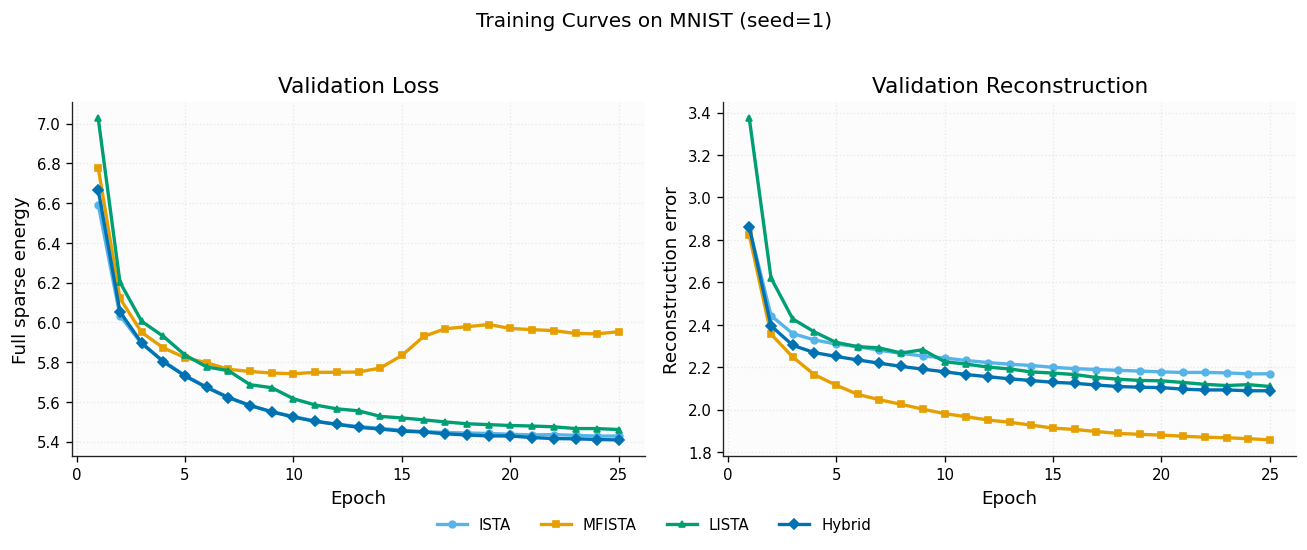

In [11]:
# ============================================================
# 2. Learning curves: epoch vs loss first
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)

for mode in MODES:
    # --- Load per-epoch metrics CSV --------------------------------------------
    epoch_path = results[mode]["run_dir"] / "epoch_metrics.csv"
    with epoch_path.open(newline="") as f:
        df = list(csv.DictReader(f))

    label = MODE_LABELS[mode]
    color = MODE_COLORS[mode]
    marker = MODE_MARKERS[mode]

    epochs = [float(row["epoch"]) for row in df]
    losses = [float(row["loss"]) for row in df]       # 全スパースエネルギー（正則化含む）
    recs   = [float(row["rec_x"]) for row in df]      # 再構成誤差のみ

    axes[0].plot(epochs, losses, color=color, marker=marker, linewidth=2, markersize=4, label=label)
    axes[1].plot(epochs, recs,   color=color, marker=marker, linewidth=2, markersize=4, label=label)

axes[0].set_title("Validation Loss")
axes[0].set_ylabel("Full sparse energy")
axes[1].set_title("Validation Reconstruction")
axes[1].set_ylabel("Reconstruction error")
for ax in axes:
    ax.set_xlabel("Epoch")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(MODES), frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(f"Training Curves on MNIST (seed={SEED})", y=1.02)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_01_epoch_curves.png", dpi=180, bbox_inches="tight")
plt.show()

---

# 3. Quality and latency

Main Figs.1と2の single-seed 簡略版です。横軸の budget は手法ごとの既定推論ステップ数で、Hybrid は `K + T_ref` として表示しています。

ISTA     budget= 50 loss=5.3567 rec=2.1222 latency=13.8660 ms/sample
MFISTA   budget= 20 loss=5.9054 rec=1.8208 latency=12.0838 ms/sample
LISTA    budget=  1 loss=5.3927 rec=2.0652 latency=0.1651 ms/sample
Hybrid   budget=  6 loss=5.3385 rec=2.0448 latency=1.6540 ms/sample


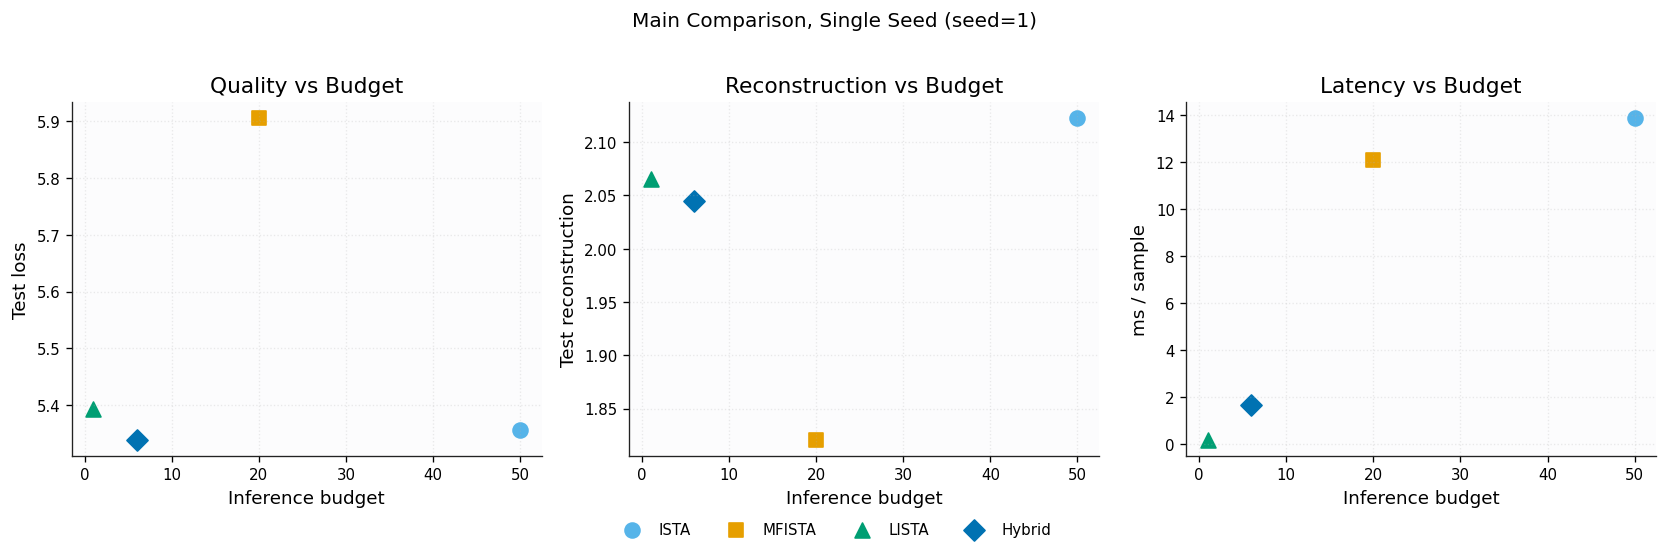

In [12]:
# ============================================================
# 3. Final quality and latency
# ============================================================

metrics = []

for mode in MODES:
    steps = METHOD_STEPS[mode]

    # --- Build evaluation-only config (no training) ----------------------------
    cfg = Config(
        mode=mode,
        layer_dims=LAYER_DIMS,
        lambdas=LAMBDAS,
        betas=BETAS,
        infer_steps=steps["infer_steps"],
        lista_steps=steps["lista_steps"],
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )

    # --- Load test data --------------------------------------------------------
    _, _, _, test_loader = make_dataset_loaders(DATASET, batch_size=BATCH_SIZE)

    # --- Collect validation snapshot -------------------------------------------
    # 1エポック分の検証データでloss / rec / latency / sparsityを一括計測
    row = collect_validation_snapshot(
        cfg=cfg,
        Ds=results[mode]["Ds"],
        infer_module=results[mode]["infer_module"],
        val_loader=test_loader,
        run_name=mode,
        epoch=EPOCHS,
        run_dir=Path("/tmp/demo_metrics"),
    )

    # --- Compute inference budget ----------------------------------------------
    # Hybrid: K (lista_steps) + T_ref (infer_steps) の合計
    # LISTA:  lista_steps のみ（反復不要）
    # その他: infer_steps のみ
    budget = steps["lista_steps"] + steps["infer_steps"] if mode == "hybrid" else steps["infer_steps"]
    if mode == "lista":
        budget = steps["lista_steps"]

    metrics.append({
        "mode": mode,
        "method": MODE_LABELS[mode],
        "budget": budget,
        "test_loss": row["loss"],
        "test_rec_x": row["rec_x"],
        "infer_time_ms": row["infer_time_ms"],
        "sparse": row["sparse"],
    })

# --- Print summary table -----------------------------------------------------
for row in metrics:
    print(f"{row['method']:<8} budget={row['budget']:>3} loss={row['test_loss']:.4f} rec={row['test_rec_x']:.4f} latency={row['infer_time_ms']:.4f} ms/sample")

# --- Scatter plots: quality/latency vs inference budget ----------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for mode in MODES:
    row = next(item for item in metrics if item["mode"] == mode)
    kwargs = dict(color=MODE_COLORS[mode], marker=MODE_MARKERS[mode], s=80, label=MODE_LABELS[mode])
    axes[0].scatter(row["budget"], row["test_loss"], **kwargs)   # 品質 vs budget
    axes[1].scatter(row["budget"], row["test_rec_x"], **kwargs)  # 再構成 vs budget
    axes[2].scatter(row["budget"], row["infer_time_ms"], **kwargs)  # レイテンシ vs budget

for ax, title, ylabel in [
    (axes[0], "Quality vs Budget", "Test loss"),
    (axes[1], "Reconstruction vs Budget", "Test reconstruction"),
    (axes[2], "Latency vs Budget", "ms / sample"),
]:
    ax.set_title(title)
    ax.set_xlabel("Inference budget")
    ax.set_ylabel(ylabel)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(MODES), frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.suptitle(f"Main Comparison, Single Seed (seed={SEED})", y=1.02)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_02_quality_latency.png", dpi=180, bbox_inches="tight")
plt.show()

---

# 4. Hybrid budget allocation

Main Fig. 3 の小型版です。学習済み Hybrid モデルを固定し、LISTA stages `K` と refinement steps `T_ref` の配分だけを変えて評価します。

K  T_ref  budget  test_loss  test_rec_x  infer_time_ms
1      0       1  5.4809     2.0612      0.1568
1      1       2  5.3836     2.0521      0.4374
1      3       4  5.3467     2.0472      1.0551
1      5       6  5.3385     2.0448      1.5627
1      7       8  5.3352     2.0434      2.0964
1     10      11  5.3328     2.0422      2.9904
2      0       2  5.4809     2.0612      0.1743
2      1       3  5.3836     2.0521      0.4954
2      3       5  5.3467     2.0472      1.0182
2      5       7  5.3385     2.0448      1.5986
2      7       9  5.3352     2.0434      2.0961
2     10      12  5.3328     2.0422      2.9404
4      0       4  5.4809     2.0612      0.1451
4      1       5  5.3836     2.0521      0.4317
4      3       7  5.3467     2.0472      1.0387
4      5       9  5.3385     2.0448      1.6657
4      7      11  5.3352     2.0434      2.2476
4     10      14  5.3328     2.0422      3.0844


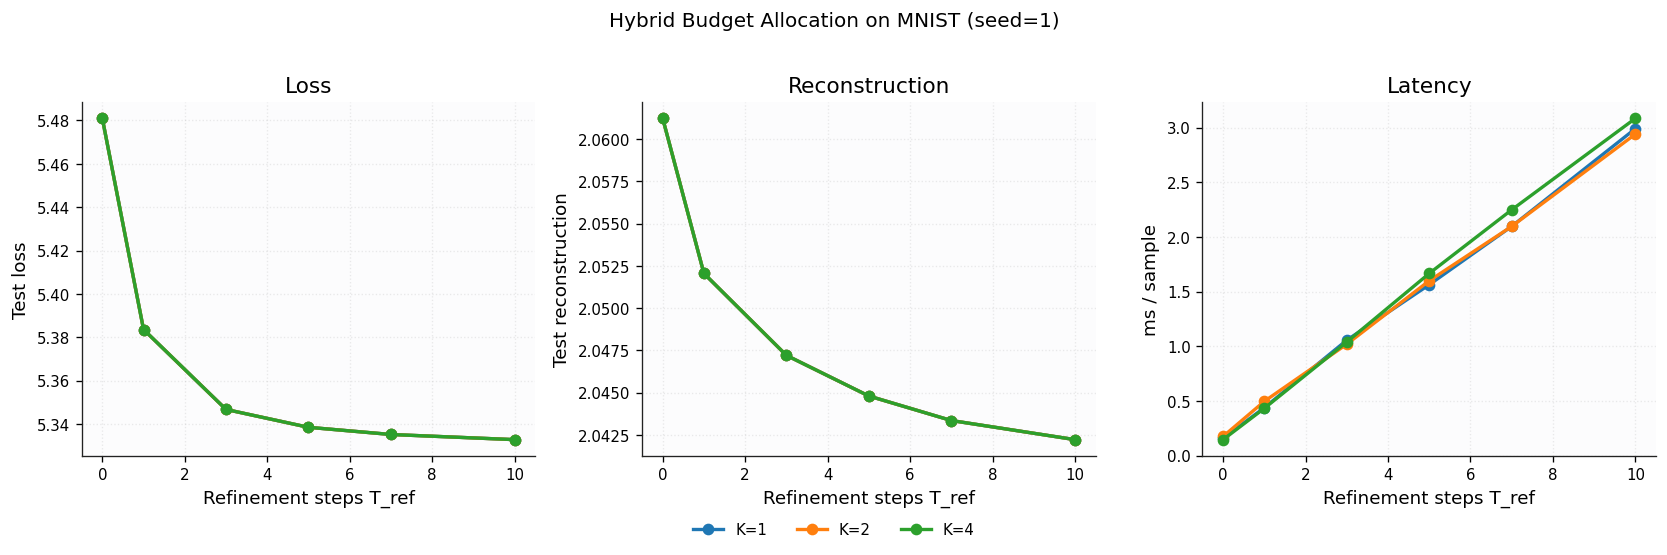

In [13]:
# ============================================================
# 4. Hybrid budget allocation: vary K and refinement steps at evaluation
# ============================================================

hybrid_rows = []

# --- Grid search over (K, T_ref) ---------------------------------------------
# K   : LISTA stage数（学習済み）
# T_ref: refinement反復回数（推論時に調整可能）
K_VALUES = [1, 2, 4]
T_REF_VALUES = [0, 1, 3, 5, 7, 10]

_, _, _, test_loader = make_dataset_loaders(DATASET, batch_size=BATCH_SIZE)

for K in K_VALUES:
    for T_ref in T_REF_VALUES:
        # --- Build eval config with this (K, T_ref) pair --------------------------
        cfg = Config(
            mode="hybrid",
            layer_dims=LAYER_DIMS,
            lambdas=LAMBDAS,
            betas=BETAS,
            infer_steps=T_ref,       # refinementステップ数
            lista_steps=K,           # LISTA stage数（学習済みモデルを流用）
            batch_size=BATCH_SIZE,
            device=DEVICE,
        )

        # --- Evaluate with the *trained* Hybrid model ----------------------------
        # 辞書Dsと推論ネットワークはseed=1で学習済みのものを再利用。
        # K/T_refを変えても同じモデルを使うので、純粋に「予算配分」の影響が見られる。
        row = collect_validation_snapshot(
            cfg=cfg,
            Ds=results["hybrid"]["Ds"],
            infer_module=results["hybrid"]["infer_module"],
            val_loader=test_loader,
            run_name=f"hybrid_K{K}_T{T_ref}",
            epoch=EPOCHS,
            run_dir=Path("/tmp/demo_hybrid_budget"),
        )

        hybrid_rows.append({
            "K": K,
            "T_ref": T_ref,
            "budget": K + T_ref,       # 総予算 = stage数 + refinement数
            "test_loss": row["loss"],
            "test_rec_x": row["rec_x"],
            "infer_time_ms": row["infer_time_ms"],
        })

# --- Print grid results ------------------------------------------------------
print("K  T_ref  budget  test_loss  test_rec_x  infer_time_ms")
for row in hybrid_rows:
    print(f"{row['K']:>1}  {row['T_ref']:>5}  {row['budget']:>6}  {row['test_loss']:.4f}     {row['test_rec_x']:.4f}      {row['infer_time_ms']:.4f}")

# --- Plot: each line is a fixed K, x-axis = T_ref ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)
for K in K_VALUES:
    sub = sorted([row for row in hybrid_rows if row["K"] == K], key=lambda row: row["T_ref"])
    t_refs = [row["T_ref"] for row in sub]
    axes[0].plot(t_refs, [row["test_loss"] for row in sub], marker="o", linewidth=2, label=f"K={K}")
    axes[1].plot(t_refs, [row["test_rec_x"] for row in sub], marker="o", linewidth=2, label=f"K={K}")
    axes[2].plot(t_refs, [row["infer_time_ms"] for row in sub], marker="o", linewidth=2, label=f"K={K}")

for ax, title, ylabel in [
    (axes[0], "Loss", "Test loss"),
    (axes[1], "Reconstruction", "Test reconstruction"),
    (axes[2], "Latency", "ms / sample"),
]:
    ax.set_title(title)
    ax.set_xlabel("Refinement steps T_ref")
    ax.set_ylabel(ylabel)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(K_VALUES), frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.suptitle(f"Hybrid Budget Allocation on MNIST (seed={SEED})", y=1.02)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_03_hybrid_budget.png", dpi=180, bbox_inches="tight")
plt.show()

---

# 5. Depth scaling

Main Fig.4の MNIST / Hybrid / single-seed 簡略版です。深さごとに Hybrid を学習し直します。


Training Hybrid depth=1, dims=[256]
save_dir = data/raw_data/hsc_hybrid_shared_20260626_151635
mode          hybrid | phase          hybrid | ep 01 step 000000 | energy 33.9268 | rec_x 31.3800 | rec_h 0.0000 | sparse 2.5468 | a1: |.|_1 0.1990, active 0.8720
mode          hybrid | phase          hybrid | ep 03 step 000500 | energy 3.6893 | rec_x 1.1274 | rec_h 0.0000 | sparse 2.5619 | a1: |.|_1 0.2001, active 0.8907
mode          hybrid | phase          hybrid | ep 05 step 001000 | energy 3.4877 | rec_x 0.9476 | rec_h 0.0000 | sparse 2.5401 | a1: |.|_1 0.1984, active 0.8538
mode          hybrid | phase          hybrid | ep 08 step 001500 | energy 3.3277 | rec_x 0.9245 | rec_h 0.0000 | sparse 2.4032 | a1: |.|_1 0.1878, active 0.8233
mode          hybrid | phase          hybrid | ep 10 step 002000 | energy 3.2941 | rec_x 0.9563 | rec_h 0.0000 | sparse 2.3379 | a1: |.|_1 0.1826, active 0.8086
mode          hybrid | phase          hybrid | ep 12 step 002500 | energy 3.1034 | rec_x 0.9078 |

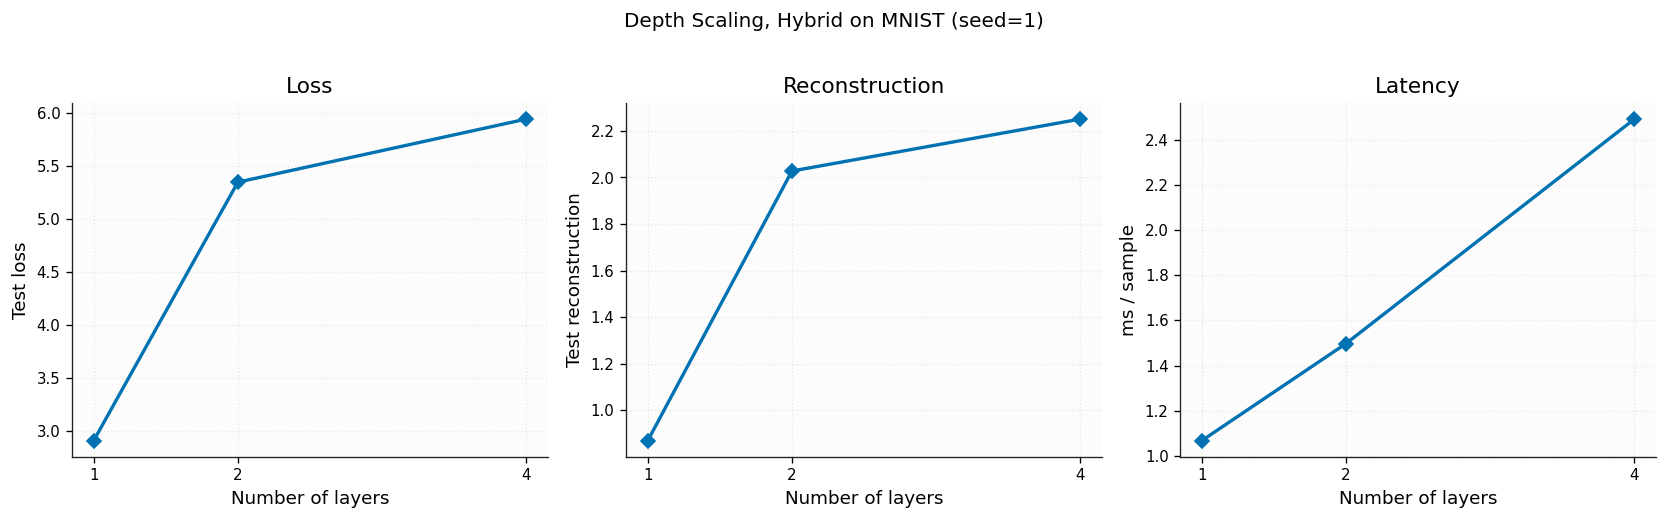

In [6]:
# ============================================================
# 5. Depth scaling: Hybrid only
# ============================================================

# --- Layer configurations per depth ------------------------------------------
# depth=1 : single-layer (256) — baseline
# depth=2 : two-layer  (256→64) — main comparison with other methods
# depth=4 : four-layer (256→192→128→64) — deep hierarchy
DEPTHS = {1: [256], 2: [256, 64], 4: [256, 192, 128, 64]}

depth_rows = []
depth_results = {}

for n_layers, dims in DEPTHS.items():
    print(f"\nTraining Hybrid depth={n_layers}, dims={dims}")

    # --- Build training config for this depth ----------------------------------
    cfg = Config(
        mode="hybrid",
        lista_variant="shared",              # 全層でパラメータ共有
        layer_dims=dims,                     # この深さに対応する次元リスト
        lambdas=[0.05] * n_layers,           # lambdaを各層分だけ展開
        betas=[1.0] * (n_layers - 1),        # betaは(層数-1)個（層間伝播ゲート）
        lr_D=1e-3,                           # 辞書更新の学習率
        lr_E=1e-3,                           # エンコーダの学習率
        infer_steps=5,                       # 推論refinementステップ数
        lista_steps=1,                       # LISTA stage数
        eta_scale=1.0,                       # etaスケール
        hybrid_pretrain_epochs=HYBRID_PRETRAIN,
                                            # Hybridは必ずpre-training（LISTA初期化用）
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        dc_center=False,                     # データ中心化なし
        print_every=500,                     # ログ出力間隔
        device=DEVICE,
    )

    # --- Train this depth ------------------------------------------------------
    artifacts = train_main(cfg, dataset_name=DATASET, seed=SEED)
    depth_results[n_layers] = artifacts   # 学習済みモデルを保存（後で使用しない）

    # --- Build evaluation config (no training params needed) -------------------
    eval_cfg = Config(
        mode="hybrid",
        layer_dims=dims,
        lambdas=[0.05] * n_layers,
        betas=[1.0] * (n_layers - 1),
        infer_steps=5,
        lista_steps=1,
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )

    # --- Evaluate on test set --------------------------------------------------
    _, _, _, test_loader = make_dataset_loaders(DATASET, batch_size=BATCH_SIZE)
    row = collect_validation_snapshot(
        cfg=eval_cfg,
        Ds=artifacts.Ds,
        infer_module=artifacts.infer_module,
        val_loader=test_loader,
        run_name=f"hybrid_L{n_layers}",
        epoch=EPOCHS,
        run_dir=Path("/tmp/demo_depth"),
    )

    depth_rows.append({
        "layers": n_layers,
        "test_loss": row["loss"],
        "test_rec_x": row["rec_x"],
        "infer_time_ms": row["infer_time_ms"],
    })

# --- Sort by layer count and print -------------------------------------------
depth_rows = sorted(depth_rows, key=lambda row: row["layers"])
print("layers  test_loss  test_rec_x  infer_time_ms")
for row in depth_rows:
    print(f"{row['layers']:>6}  {row['test_loss']:.4f}     {row['test_rec_x']:.4f}      {row['infer_time_ms']:.4f}")

# --- Plot: x-axis = number of layers -----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)
for ax, metric, title, ylabel in [
    (axes[0], "test_loss", "Loss", "Test loss"),
    (axes[1], "test_rec_x", "Reconstruction", "Test reconstruction"),
    (axes[2], "infer_time_ms", "Latency", "ms / sample"),
]:
    ax.plot([row["layers"] for row in depth_rows], [row[metric] for row in depth_rows], marker="D", linewidth=2, color=MODE_COLORS["hybrid"])
    ax.set_title(title)
    ax.set_xlabel("Number of layers")
    ax.set_ylabel(ylabel)
    ax.set_xticks([row["layers"] for row in depth_rows])

fig.suptitle(f"Depth Scaling, Hybrid on MNIST (seed={SEED})", y=1.02)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_04_depth_scaling.png", dpi=180, bbox_inches="tight")
plt.show()

---

# 6. Sparsity sweep

論文 Fig.5に合わせて、`lambda` を変えたときの再構成誤差と平均非零率を見ます。
デモの実行時間を抑えるため、ここでは **Hybrid と MFISTA のみ**、single seed / MNIST で学習し直します。



Training MFISTA with lambda=0.02 (seed=1)
save_dir = /tmp/demo_sparsity_sweep/hsc_mfista_shared_20260626_151817
mode          mfista | phase          mfista | ep 01 step 000000 | energy 37.2553 | rec_x 33.7179 | rec_h 2.4917 | sparse 1.0456 | a1: |.|_1 0.1507, active 0.9393 | a2: |.|_1 0.2141, active 0.8634
mode          mfista | phase          mfista | ep 01 step 000200 | energy 5.0050 | rec_x 2.5952 | rec_h 0.5213 | sparse 1.8886 | a1: |.|_1 0.2501, active 0.9701 | a2: |.|_1 0.4750, active 0.9848
mode          mfista | phase          mfista | ep 02 step 000400 | energy 4.2955 | rec_x 1.9829 | rec_h 0.5672 | sparse 1.7453 | a1: |.|_1 0.2307, active 0.9650 | a2: |.|_1 0.4409, active 0.9828
mode          mfista | phase          mfista | ep 03 step 000600 | energy 4.2361 | rec_x 1.8718 | rec_h 0.6254 | sparse 1.7388 | a1: |.|_1 0.2292, active 0.9620 | a2: |.|_1 0.4415, active 0.9774
mode          mfista | phase          mfista | ep 04 step 000800 | energy 3.9080 | rec_x 1.6269 | rec_h 0

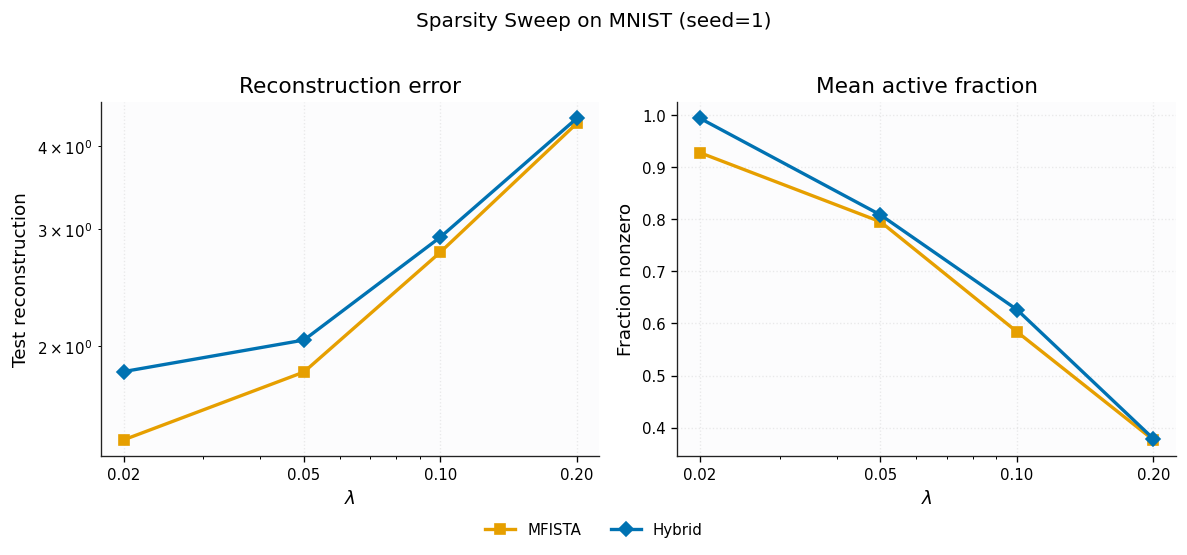

In [7]:
# ============================================================
# 6. Sparsity sweep: Hybrid and MFISTA, paper-style small demo
# ============================================================

SPARSITY_SWEEP_LAMBDAS = [0.02, 0.05, 0.10, 0.20]
SPARSITY_SWEEP_MODES = ["mfista", "hybrid"]
SPARSITY_SWEEP_EPOCHS = EPOCHS
SPARSITY_RUN_ROOT = Path("/tmp/demo_sparsity_sweep")

_, _, _, test_loader = make_dataset_loaders(DATASET, batch_size=BATCH_SIZE)
sparsity_sweep_rows = []
sparsity_sweep_results = {}

for lambda_value in SPARSITY_SWEEP_LAMBDAS:
    lambda_list = [lambda_value for _ in LAYER_DIMS]

    for mode in SPARSITY_SWEEP_MODES:
        steps = METHOD_STEPS[mode]
        run_name = f"sparsity_{mode}_lambda{lambda_value:g}".replace(".", "p")

        print("\n" + "=" * 64)
        print(f"Training {MODE_LABELS[mode]} with lambda={lambda_value:g} (seed={SEED})")
        print("=" * 64)

        cfg = Config(
            mode=mode,
            layer_dims=LAYER_DIMS,
            lambdas=lambda_list,
            betas=BETAS,
            epochs=SPARSITY_SWEEP_EPOCHS,
            batch_size=BATCH_SIZE,
            infer_steps=steps["infer_steps"],
            lista_steps=steps["lista_steps"],
            hybrid_pretrain_epochs=HYBRID_PRETRAIN if mode == "hybrid" else 0,
            device=DEVICE,
            save_root=SPARSITY_RUN_ROOT,
        )

        artifacts = train_main(cfg, dataset_name=DATASET, seed=SEED)
        sparsity_sweep_results[(mode, lambda_value)] = artifacts

        # Re-evaluate on the test split so the printed table and figure use the same loader.
        test_row = collect_validation_snapshot(
            cfg=cfg,
            Ds=artifacts.Ds,
            infer_module=artifacts.infer_module,
            val_loader=test_loader,
            run_name=run_name,
            epoch=SPARSITY_SWEEP_EPOCHS,
            run_dir=artifacts.run_dir,
        )

        active_values = [test_row[f"a{layer}_active_frac"] for layer in range(1, len(LAYER_DIMS) + 1)]
        sparsity_sweep_rows.append({
            "method": MODE_LABELS[mode],
            "mode": mode,
            "lambda": lambda_value,
            "rec_x": test_row["rec_x"],
            "mean_active_frac": float(np.mean(active_values)),
            **{f"a{layer}_active_frac": active_values[layer - 1] for layer in range(1, len(LAYER_DIMS) + 1)},
        })

print("\nmethod   lambda  rec_x   mean_active  layer1_active  layer2_active")
for row in sorted(sparsity_sweep_rows, key=lambda r: (r["mode"], r["lambda"])):
    print(
        f"{row['method']:<8} {row['lambda']:<6.2f} "
        f"{row['rec_x']:.4f}  {row['mean_active_frac']:.4f}       "
        f"{row['a1_active_frac']:.4f}         {row['a2_active_frac']:.4f}"
    )

# --- Plot: same two quantities as the paper sparsity-sweep figure -------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True)
for mode in SPARSITY_SWEEP_MODES:
    sub = sorted([row for row in sparsity_sweep_rows if row["mode"] == mode], key=lambda row: row["lambda"])
    lambdas_x = [row["lambda"] for row in sub]
    axes[0].plot(
        lambdas_x,
        [row["rec_x"] for row in sub],
        marker=MODE_MARKERS[mode],
        color=MODE_COLORS[mode],
        linewidth=2,
        label=MODE_LABELS[mode],
    )
    axes[1].plot(
        lambdas_x,
        [row["mean_active_frac"] for row in sub],
        marker=MODE_MARKERS[mode],
        color=MODE_COLORS[mode],
        linewidth=2,
        label=MODE_LABELS[mode],
    )

axes[0].set_title("Reconstruction error")
axes[0].set_ylabel("Test reconstruction")
axes[0].set_yscale("log")
axes[1].set_title("Mean active fraction")
axes[1].set_ylabel("Fraction nonzero")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel(r"$\lambda$")
    ax.set_xticks(SPARSITY_SWEEP_LAMBDAS)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(SPARSITY_SWEEP_MODES), frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.suptitle(f"Sparsity Sweep on MNIST (seed={SEED})", y=1.02)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_05_sparsity.png", dpi=180, bbox_inches="tight")
plt.show()


---

# 7. Learned dictionaries and reconstructions

最後に定性的な確認として、学習された辞書原子と再構成例を表示します。

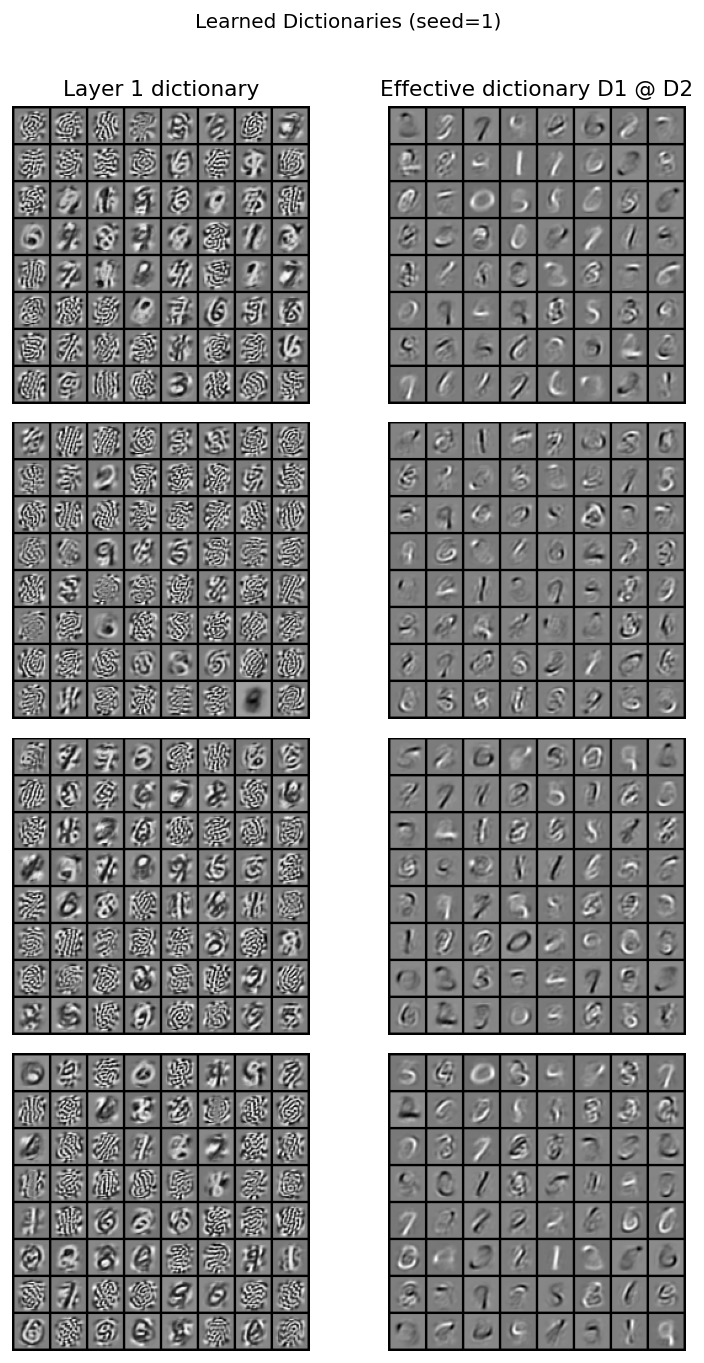

In [8]:
# ============================================================
# 7a. Learned dictionaries
# ============================================================

H, W = 28, 28   # MNIST画像の縦横ピクセル

fig, axes = plt.subplots(len(MODES), 2, figsize=(7, 2.8 * len(MODES)))

for row_idx, mode in enumerate(MODES):
    Ds = results[mode]["Ds"]

    # --- Compute effective dictionary -------------------------------------------
    # Effective dict = D1 @ D2 （第1層辞書 × 第2層辞書）
    # これは「入力を直接写像する合成辞書」で、2層ネットワークの全体像を把握できる。
    eff_dicts = compute_effective_dictionaries([d.detach() for d in Ds])

    # --- Save and display Layer 1 dictionary ------------------------------------
    d1_path = Path("/tmp") / f"demo_dict_l1_{mode}.png"
    save_dictionary_grid(Ds[0], H, W, str(d1_path), n_show=64)  # 原子を64個表示

    axes[row_idx, 0].imshow(plt.imread(d1_path))
    axes[row_idx, 0].axis("off")
    axes[row_idx, 0].set_ylabel(MODE_LABELS[mode], rotation=0, labelpad=30, va="center")

    # --- Save and display Effective dictionary (D1 @ D2) ------------------------
    eff_path = Path("/tmp") / f"demo_dict_eff_{mode}.png"
    save_dictionary_grid(eff_dicts[1], H, W, str(eff_path), n_show=64)

    axes[row_idx, 1].imshow(plt.imread(eff_path))
    axes[row_idx, 1].axis("off")

axes[0, 0].set_title("Layer 1 dictionary")
axes[0, 1].set_title("Effective dictionary D1 @ D2")
fig.suptitle(f"Learned Dictionaries (seed={SEED})", y=1.01)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_06_dictionaries.png", dpi=180, bbox_inches="tight")
plt.show()

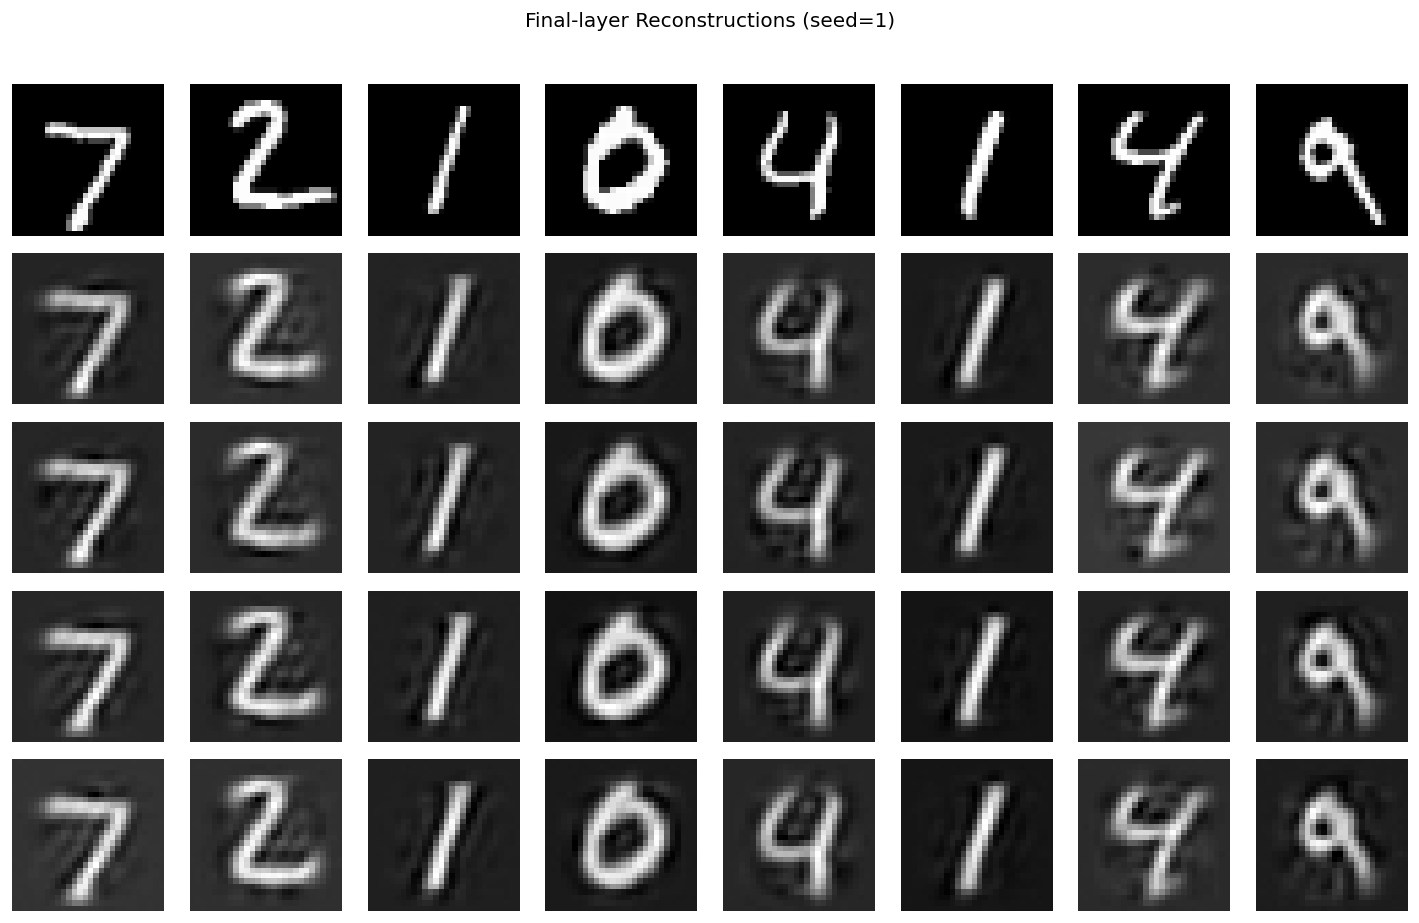

In [9]:
# ============================================================
# 7b. Reconstruction examples
# ============================================================

_, _, _, test_loader = make_dataset_loaders(DATASET, batch_size=8)
test_images, _ = next(iter(test_loader))
x = prepare_eval_batch(Config(device=DEVICE), test_images)
n_show = min(8, x.shape[0])

recon_by_mode = {}
for mode in MODES:
    steps = METHOD_STEPS[mode]

    # --- Build evaluation config ------------------------------------------------
    cfg = Config(
        mode=mode,
        layer_dims=LAYER_DIMS,
        lambdas=LAMBDAS,
        betas=BETAS,
        infer_steps=steps["infer_steps"],
        lista_steps=steps["lista_steps"],
        batch_size=8,
        device=DEVICE,
    )

    Ds = results[mode]["Ds"]

    # --- Build inference context ------------------------------------------------
    Ds_for_inf, lambdas, betas, etas = build_eval_inference_context(
        cfg, [d.detach() for d in Ds]
    )

    # --- Run inference to get codes ---------------------------------------------
    codes = results[mode]["infer_module"](
        x=x,
        Ds_for_inference=Ds_for_inf,
        lambdas=lambdas,
        betas=betas,
        infer_steps=steps["infer_steps"],
        eta_scale=1.0,
        etas=etas,
    )

    # --- Reconstruct from the last layer's code ---------------------------------
    # 最終層のコード × 有効辞書 → 再構成画像
    # codes[-1] = 最下層（第2層）の活性化、eff_dicts[-1] = D1 @ D2 の合成辞書
    eff_dicts = compute_effective_dictionaries([d.detach() for d in Ds])
    recon_by_mode[mode] = (codes[-1].detach().cpu() @ eff_dicts[-1].detach().cpu().t()).view(-1, H, W)

# --- Display: row 0 = input, subsequent rows = reconstruction per method ------
fig, axes = plt.subplots(1 + len(MODES), n_show, figsize=(1.5 * n_show, 1.5 * (1 + len(MODES))))

x_cpu = x.detach().cpu().view(-1, H, W)
for col in range(n_show):
    # Input row
    axes[0, col].imshow(x_cpu[col], cmap="gray")
    axes[0, col].axis("off")
    if col == 0:
        axes[0, col].set_ylabel("Input", rotation=0, labelpad=28, va="center")

for row_idx, mode in enumerate(MODES, start=1):
    x_rec = recon_by_mode[mode]
    for col in range(n_show):
        axes[row_idx, col].imshow(x_rec[col], cmap="gray")
        axes[row_idx, col].axis("off")
        if col == 0:
            axes[row_idx, col].set_ylabel(MODE_LABELS[mode], rotation=0, labelpad=28, va="center")

fig.suptitle(f"Final-layer Reconstructions (seed={SEED})", y=1.02)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_07_reconstructions.png", dpi=180, bbox_inches="tight")
plt.show()